**Project Objective**

The objective of this project is to perform an exploratory data analysis by creating clusters based on the variables "Age" and "Income" using the K-Means model. The dataset used was obtained from Kaggle.

**Null and Duplicate Analysis**

The dataset contains no missing values and no duplicate records.

**Elbow Method Analysis**

Based on the Elbow method analysis, it was possible to determine that the optimal number of clusters is 5, as this is the point where the curve begins to stabilize.

**Conclusion**

The Silhouette Score ranges from -1 to 1 and measures how close a data point is to its own cluster compared to other clusters. In this case, the score was 0.54, indicating good cluster separation.

The Davies-Bouldin Index measures the similarity between clusters. In this case, it has a low value (0.52), indicating a good model.

The Calinski-Harabasz Index measures the dispersion between clusters relative to the dispersion within clusters. The value obtained was 5316, which is high and also indicates a good model.

From the ANOVA F-test results (p-value < 0.05), it can be observed that "Income" shows greater differentiation across clusters than "Age", indicating it better characterizes the cluster separation, rather than having a greater impact on cluster formation.

In [ ]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from scipy.stats import f_oneway

In [ ]:
# DataFrame
df = pd.read_csv("C:\\Users\\Clayton Miranda\\Desktop\\Modelos\\Datasets\\Cluster z\\segmentation data.csv")

In [ ]:
# DF - Display

display(df)

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...,...
1995,100001996,1,0,47,1,123525,0,0
1996,100001997,1,1,27,1,117744,1,0
1997,100001998,0,0,31,0,86400,0,0
1998,100001999,1,1,24,1,97968,0,0


In [ ]:
# DF - Info

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


None

In [ ]:
# DF - Describe

display(df.describe())

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [ ]:
# Duplicate analises

display(df.duplicated().value_counts())

False    2000
Name: count, dtype: int64

In [ ]:
# Removing other columns

df_age_inc = df[['Age', 'Income']]

c:\Users\Clayton Miranda\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Clayton Miranda\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
c:\Users\Clayton Miranda\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Clayton Miranda\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. Y

[2903113028798.3154, 1214580023983.0764, 673028151954.4475, 377140788953.42053, 248987937927.16388, 176760000595.55432, 129552812059.40987, 96312226058.18024, 78557727901.4885, 64553367247.038605]


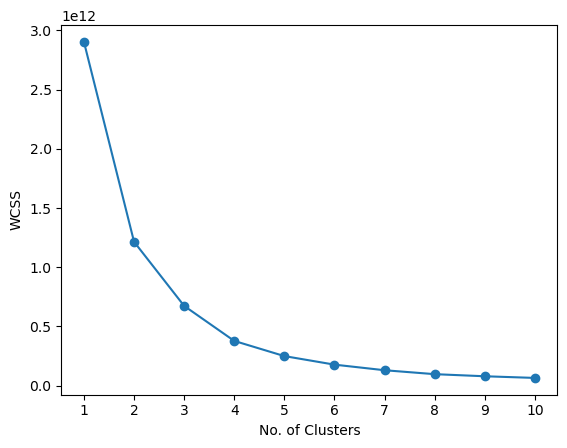

In [28]:
# Kmens (Age / Income)  - Elbow

wcss=[]

for k in range(1,11):
    kmeans = KMeans(n_clusters = k, init = 'k-means++')
    kmeans.fit(df_age_inc)
    wcss.append(kmeans.inertia_)

print(wcss)

plt.plot(range(1,11), wcss, marker='o')
plt.xticks(range(1,11))
plt.xlabel('No. of Clusters')
plt.ylabel('WCSS')
plt.show()

c:\Users\Clayton Miranda\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Clayton Miranda\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(
C:\Users\Clayton Miranda\AppData\Local\Temp\ipykernel_26116\2268400219.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age_inc['Cluster'] = y_kmeans


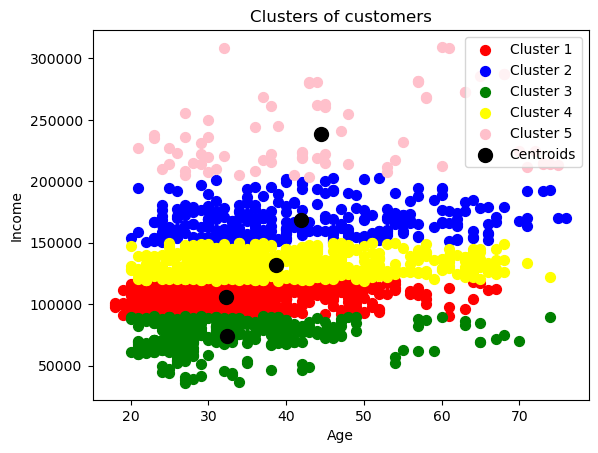

In [ ]:
# Training the KMeans model

kmeans = KMeans(n_clusters = 5, init = 'k-means++')
y_kmeans = kmeans.fit_predict(df_age_inc)
y_kmeans = pd.DataFrame(y_kmeans)
df_age_inc['Cluster'] = y_kmeans

plt.scatter(df_age_inc.loc[df_age_inc['Cluster'] == 0, 'Age'], df_age_inc.loc[df_age_inc['Cluster'] == 0, 'Income'], s=50, c='red', label='Cluster 1')

plt.scatter(df_age_inc.loc[df_age_inc['Cluster'] == 1, 'Age'], df_age_inc.loc[df_age_inc['Cluster'] == 1, 'Income'], s=50, c='blue', label='Cluster 2')

plt.scatter(df_age_inc.loc[df_age_inc['Cluster'] == 2, 'Age'], df_age_inc.loc[df_age_inc['Cluster'] == 2, 'Income'], s=50, c='green', label='Cluster 3')

plt.scatter(df_age_inc.loc[df_age_inc['Cluster'] == 3, 'Age'], df_age_inc.loc[df_age_inc['Cluster'] == 3, 'Income'], s=50, c='yellow', label='Cluster 4')

plt.scatter(df_age_inc.loc[df_age_inc['Cluster'] == 4, 'Age'], df_age_inc.loc[df_age_inc['Cluster'] == 4, 'Income'], s=50, c='pink', label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='black', label='Centroids')

plt.title('Clusters of customers')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()
plt.show()

In [36]:
# Mean by Cluster

df_age_inc.groupby('Cluster').mean()

,Age,Income
Cluster,,
0,32.297222,105851.429167
1,41.967857,168190.928571
2,32.459016,74376.442623
3,38.652406,131889.044563
4,44.506849,238230.369863


In [31]:
# F and p-value by feature

for col in ['Age', 'Income']:
    grupos = [df_age_inc[df_age_inc['Cluster'] == c][col] for c in df_age_inc['Cluster'].unique()]
    stat, p = f_oneway(*grupos)
    
    print(f'{col}: F={stat:.2f}, p-value={p:.5f}')

Age: F=69.66, p-value=0.00000
Income: F=5316.52, p-value=0.00000


In [ ]:
# Silhoutte

silhouette_score(df_age_inc[['Age', 'Income']], df_age_inc['Cluster'])

0.5401520680025738

In [ ]:
# Davies-Bouldin

davies_bouldin_score(df_age_inc[['Age', 'Income']], df_age_inc['Cluster'])

0.5253791321528432

In [ ]:
# Calinski-Harabasz

calinski_harabasz_score(df_age_inc[['Age', 'Income']], df_age_inc['Cluster'])

5316.514630504947